# METEOR-Impacts Clean Demo: Climate Degree Days Calculation

This notebook demonstrates the complete METEOR-impacts workflow for calculating heating and cooling degree days from CMIP6 climate projections. It showcases the integration of:

1. **METEOR Pattern Scaling**: Generate climate projections from emissions scenarios
2. **METEOR-Noise**: Add realistic monthly climate variability 
3. **METEOR-Impacts**: Calculate climate impact metrics (degree days) using refactored, production-ready code

## Key Features

- Uses the new `meteor.impacts` module with Isaac & van Vuuren (2009) methodology
- Clean, efficient workflow with minimal redundancy
- Demonstrates ensemble generation and uncertainty quantification
- Shows practical application for specific locations (Oslo example)

This replaces the previous ad-hoc degree days calculation with a robust, tested, and extensible impacts framework.

## 1. Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import warnings

# METEOR core modules
from meteor import MeteorPatternScaling, geo_data_utils, Cmip6MeteorDataGetter
from meteor.noise_generator import MeteorNoiseGenerator, train_noise_model_from_cmip6

# METEOR-impacts module (new refactored code)
from meteor.impacts import DegreeDaysCalculator, ImpactEnsemble

# Climate forcing data
from ciceroscm import input_handler

# Configure warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", message=".*not in pamset.*")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 2. Setup Configuration

In [2]:
# Configuration
SCENARIO = "ssp245"  # Focus on moderate warming scenario
MODEL = "CanESM5"    # Use CanESM5 for demonstration

# Data directories
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")
noise_cache_dir = os.path.join(os.getcwd(), "noise_cache")

# Climate scenarios to process
scenarios = ["ssp126", "ssp245", "ssp585"]
fields = ["tas", "pr"]  # Temperature and precipitation

# Oslo coordinates for regional analysis
OSLO_LAT = 59.91
OSLO_LON = 10.75

# Degree days base temperature (18°C commonly used for energy applications)
BASE_TEMPERATURE = 18.0

print(f"✅ Configuration set:")
print(f"   Model: {MODEL}")
print(f"   Primary scenario: {SCENARIO}")
print(f"   Base temperature: {BASE_TEMPERATURE}°C")
print(f"   Oslo location: {OSLO_LAT}°N, {OSLO_LON}°E")

✅ Configuration set:
   Model: CanESM5
   Primary scenario: ssp245
   Base temperature: 18.0°C
   Oslo location: 59.91°N, 10.75°E


## 3. Initialize CMIP6 Data Access

In [3]:
# Initialize CMIP6 data getter
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "abrupt-4xCO2", "1pctCO2", "historical"] + scenarios,
    flds=fields,
    dbe=['CMIP', 'CMIP', 'CMIP', 'CMIP', 'ScenarioMIP', 'ScenarioMIP', 'ScenarioMIP']
)

# Available models with complete data
available_models = data_getter.models
print(f"✅ CMIP6 data getter initialized")
print(f"   Available models: {len(available_models)}")
print(f"   Using model: {MODEL}")
print(f"   Fields: {fields}")
print(f"   Scenarios: {scenarios}")

# Verify our chosen model is available
if MODEL not in available_models:
    print(f"⚠️  Warning: {MODEL} not in available models: {available_models}")
    MODEL = available_models[0]  # Use first available model
    print(f"   Switching to: {MODEL}")

✅ CMIP6 data getter initialized
   Available models: 38
   Using model: CanESM5
   Fields: ['tas', 'pr']
   Scenarios: ['ssp126', 'ssp245', 'ssp585']


## 4. Load Climate Forcing Data

In [4]:
# Load concentration and emission data for climate forcing
ih = input_handler.InputHandler({})

conc_data = []
em_data = []

for scenario in scenarios:
    # Load concentration data
    conc_file = os.path.join(cscm_data_dir, f"{scenario}_conc_RCMIP.txt")
    conc_data.append(input_handler.read_inputfile(conc_file))
    
    # Load emission data
    em_file = os.path.join(cscm_data_dir, f"{scenario}_em_RCMIP.txt")
    em_data.append(ih.read_emissions(em_file))

print(f"✅ Climate forcing data loaded for {len(scenarios)} scenarios")
print(f"   Concentration datasets: {len(conc_data)}")
print(f"   Emission datasets: {len(em_data)}")

✅ Climate forcing data loaded for 3 scenarios
   Concentration datasets: 3
   Emission datasets: 3


## 5. Load Training Data

In [5]:
def load_training_data():
    """Load or generate CMIP6 training data with caching."""
    
    
    training_data = {
        "base": data_getter.make_meteor_training_data("base", MODEL),
        "co2x4": data_getter.make_meteor_training_data("co2x4", MODEL),
        "1pc": data_getter.make_meteor_training_data("1pc", MODEL)
    }
    
    # Add scenario data
    for scenario in scenarios:
        training_data[scenario] = data_getter.make_meteor_training_data_composite(
            ["historical", scenario], MODEL
        )
    
    return training_data

# Load the training data
training_data = load_training_data()

print(f"✅ Training data loaded for {MODEL}")
print(f"   Experiments: {list(training_data.keys())}")
print(f"   Fields available: {list(training_data['base'].data_vars)}")

   Limiting piControl data to first 150 years (was 1051 years)


   Limiting piControl data to first 150 years (was 1051 years)


✅ Training data loaded for CanESM5
   Experiments: ['base', 'co2x4', '1pc', 'ssp126', 'ssp245', 'ssp585']
   Fields available: ['tas', 'pr']


## 6. Create METEOR Pattern Scaling Models

In [6]:
# Create pattern scaling models

# Model 1: Pure CO2 response (GHG-only)
print("🔧 Creating GHG-only pattern scaling model...")
ghg_pattern = MeteorPatternScaling(
    f"cmip6-{MODEL}-ghg",
    {"tas": 2, "pr": 2},  # 2 patterns for each field
    lambda key: training_data[key],
    from_file=False,
    exp_list=["base", "co2x4"]
)

# Model 2: Include aerosol effects (more realistic)
print("🔧 Creating aerosol-inclusive pattern scaling model...")
# Use the primary scenario as the aerosol anomaly experiment
training_data["sulxanom"] = training_data[SCENARIO]

aer_pattern = MeteorPatternScaling(
    f"cmip6-{MODEL}-aer",
    {"tas": 2, "pr": 2},
    lambda key: training_data[key],
    from_file=False,
    exp_list=["base", "co2x4", "sulxanom"]
)

print(f"✅ Pattern scaling models created")
print(f"   GHG-only model: {ghg_pattern.name}")
print(f"   Aerosol-inclusive model: {aer_pattern.name}")

/Users/bensan/Documents/Github/METEOR/src/meteor/scm_forcer_engine.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.concentrations_data.loc[self.emstart : self.emstart + 6].iloc[:] = (
/Users/bensan/Documents/Github/METEOR/src/meteor/scm_forcer_engine.py:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.emissions_data.loc[self.emstart : self.emstart + 6].iloc[:] = (


/Users/bensan/Documents/Github/METEOR/src/meteor/scm_forcer_engine.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.concentrations_data.loc[self.emstart : self.emstart + 6].iloc[:] = (
/Users/bensan/Documents/Github/METEOR/src/meteor/scm_forcer_engine.py:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.emissions_data.loc[self.emstart : self.emstart + 6].iloc[:] = (


🔧 Creating GHG-only pattern scaling model...
11
12
113
114
115
22
141
123
142
11
12
113
114
115
22
141
123
142

[PATTERN SCALING DEBUG]
  n_modes: 2
  ampguess: 3.315115e-02
  tguess: [ 5 50]
  a0 (initial guesses): [3.31511497e-02 5.00000000e+00 3.31511497e-02 5.00000000e+01]
  anomaly_data shape: (100, 64, 128)
  anomaly_data NaN count: 0
  anomaly_data range: [-9.002136e+00, 8.352814e+00]

[FIT_TIMESCALES DEBUG]
  Computing global mean timeseries...
  Timeseries length: 100
  Timeseries NaN count: 0
  Final timeseries length: 100
  Timeseries Inf count: 0
  Timeseries range: [-1.200156e-01, 1.694284e-01]
  Timeseries mean: 1.002112e-02
  Timeseries std: 5.870589e-02
  First 5 values: [0.03992936 0.03824895 0.00381398 0.0031423  0.00470446]
  Initial parameters: {'t0': 5.0, 's0': 0.03315114974975586, 't1': 50.0, 's1': 0.03315114974975586}
  Initial residual NaN count: 0
  Initial residual sum: 5.089952e-01
  Starting lmfit.minimize...
  Optimization complete. Success: True
  Message:

/Users/bensan/Documents/Github/METEOR/src/meteor/scm_forcer_engine.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.concentrations_data.loc[self.emstart : self.emstart + 6].iloc[:] = (
/Users/bensan/Documents/Github/METEOR/src/meteor/scm_forcer_engine.py:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.emissions_data.loc[self.emstart : self.emstart + 6].iloc[:] = (


11
12
113
114
115
22
141
123
142

[PATTERN SCALING DEBUG]
  n_modes: 2
  ampguess: 3.315115e-02
  tguess: [ 5 50]
  a0 (initial guesses): [3.31511497e-02 5.00000000e+00 3.31511497e-02 5.00000000e+01]
  anomaly_data shape: (100, 64, 128)
  anomaly_data NaN count: 0
  anomaly_data range: [-9.002136e+00, 8.352814e+00]

[FIT_TIMESCALES DEBUG]
  Computing global mean timeseries...
  Timeseries length: 100
  Timeseries NaN count: 0
  Final timeseries length: 100
  Timeseries Inf count: 0
  Timeseries range: [-1.200156e-01, 1.694284e-01]
  Timeseries mean: 1.002112e-02
  Timeseries std: 5.870589e-02
  First 5 values: [0.03992936 0.03824895 0.00381398 0.0031423  0.00470446]
  Initial parameters: {'t0': 5.0, 's0': 0.03315114974975586, 't1': 50.0, 's1': 0.03315114974975586}
  Initial residual NaN count: 0
  Initial residual sum: 5.089952e-01
  Starting lmfit.minimize...
  Optimization complete. Success: True
  Message: Fit succeeded.

[PATTERN SCALING DEBUG]
  n_modes: 2
  ampguess: 1.783816e-08

✅ Pattern scaling models created
   GHG-only model: cmip6-CanESM5-ghg
   Aerosol-inclusive model: cmip6-CanESM5-aer


## 7. Generate Climate Predictions

In [7]:
# Generate climate predictions for our primary scenario
scenario_idx = scenarios.index(SCENARIO)

print(f"🌍 Generating climate predictions for {SCENARIO}...")
print(f"   Scenario index: {scenario_idx}")
print(f"   Available scenarios: {scenarios}")

# Debug: Check what data we have
print(f"🔍 Debugging data availability:")
print(f"   Emission data length: {len(em_data)}")
print(f"   Concentration data length: {len(conc_data)}")
print(f"   Aerosol pattern available: {hasattr(aer_pattern, 'predict_from_combined_experiment')}")

try:
    # Generate predictions using aerosol-inclusive model (more realistic)
    print(f"   Calling predict_from_combined_experiment...")
    climate_prediction = aer_pattern.predict_from_combined_experiment(
        em_data[scenario_idx], 
        conc_data[scenario_idx], 
        fields
    )

    # Extract temperature field for further processing
    temperature_prediction = climate_prediction["tas"]

    # Calculate baseline from control simulation
    baseline_temp = np.mean(geo_data_utils.global_mean(training_data["base"]["tas"]).values)

    print(f"✅ Climate predictions generated successfully")
    print(f"   Scenario: {SCENARIO}")
    print(f"   Temperature shape: {temperature_prediction.shape}")
    print(f"   Temperature coordinates: {list(temperature_prediction.coords)}")
    print(f"   Baseline temperature: {baseline_temp:.2f} K")
    
    if hasattr(temperature_prediction, 'year'):
        print(f"   Prediction years: {temperature_prediction.year.values[0]:.0f}-{temperature_prediction.year.values[-1]:.0f}")
    else:
        print(f"   No 'year' coordinate found. Available coordinates: {list(temperature_prediction.coords)}")
        
except Exception as e:
    print(f"❌ Error in climate prediction generation:")
    print(f"   Error type: {type(e).__name__}")
    print(f"   Error message: {str(e)}")
    print(f"   Available pattern methods: {[m for m in dir(aer_pattern) if not m.startswith('_')]}")
    raise

🌍 Generating climate predictions for ssp245...
   Scenario index: 1
   Available scenarios: ['ssp126', 'ssp245', 'ssp585']
🔍 Debugging data availability:
   Emission data length: 3
   Concentration data length: 3
   Aerosol pattern available: True
   Calling predict_from_combined_experiment...
11
12
113
114
115
22
141
123
142


✅ Climate predictions generated successfully
   Scenario: ssp245
   Temperature shape: (351, 64, 128)
   Temperature coordinates: ['lat', 'lon', 'time']
   Baseline temperature: 286.47 K
   No 'year' coordinate found. Available coordinates: ['lat', 'lon', 'time']


## 8. Train Noise Model and Generate Ensemble

In [8]:
# Convert annual predictions to monthly for noise model training
print("📊 Preparing data for noise model...")

# Convert METEOR predictions to monthly resolution
monthly_prediction = aer_pattern.to_monthly(temperature_prediction, start_year=0)
monthly_warming = geo_data_utils.global_mean(monthly_prediction).values

# Skip first 100 years (spin-up period)
monthly_warming_trimmed = monthly_warming[1200:]  # 100 years * 12 months

print(f"🔧 Training noise model...")

# Train noise model with custom global temperature trajectory
tas_noise_model = train_noise_model_from_cmip6(
    data_getter,
    experiments=["historical", SCENARIO],
    model_name=MODEL,
    variable_name="tas",
    n_modes=8,  # Principal components for variability
    lag_order=2,  # Temporal correlation
    custom_global_temp=monthly_warming_trimmed,
    use_picontrol_baseline=True,
    cache_dir=noise_cache_dir
)

print(f"✅ Noise model trained")
print(f"   Modes: 8 PCA components")
print(f"   Temporal lag: 2 months")
print(f"   Training period: {len(monthly_warming_trimmed)//12} years")

📊 Preparing data for noise model...
🔧 Training noise model...


   Limiting piControl data to first 150 years (was 1051 years)


   Fetched piControl baseline for CanESM5 tas: 277.178
8 2


Noise generator fitted successfully.
   - PCA modes: 8
   - Variance explained: 68.68%
   - VARX lag order: 2
   - Exogenous vars: t_glob only
Model saved to /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/CanESM5_tas_noise_model.pkl
✅ Noise model trained
   Modes: 8 PCA components
   Temporal lag: 2 months
   Training period: 251 years


In [9]:
# Generate synthetic climate ensemble with proper monthly seasonal cycles
print("🎲 Generating synthetic climate ensemble with seasonal cycles...")

n_realizations = 2

# STEP 1: Generate monthly climatology from METEOR pattern scaling
print("   Step 1: Converting annual patterns to monthly climatology...")

# Convert METEOR annual predictions to monthly resolution using built-in method
monthly_climatology = aer_pattern.to_monthly(temperature_prediction, start_year=0)
print(f"   Monthly climatology shape: {monthly_climatology.shape}")
print(f"   Monthly climatology coords: {list(monthly_climatology.coords)}")

# STEP 2: Load training data with monthly resolution for noise model baseline
print("   Step 2: Loading monthly training data...")

# Get monthly training data (this includes seasonal cycles)
monthly_training = data_getter.make_meteor_training_data_composite(
    ["historical", SCENARIO], MODEL, monthly=True
)

print(f"   Monthly training data shape: {monthly_training['tas'].shape}")
print(f"   Monthly training dims: {monthly_training['tas'].dims}")

# STEP 3: Generate ensemble using noise model + monthly climatology
print("   Step 3: Generating ensemble realizations...")

climate_ensemble = []

for i in range(n_realizations):
    print(f"   Generating realization {i+1}/{n_realizations}")
    
    # Generate noise-only realization using the trained noise model
    noise_realization = tas_noise_model.generate_realization(
        monthly_warming,
        noise_only=True,
        random_seed=42 + i
    )
    
    # Interpolate annual training data to monthly resolution to add climatology
    annual_data = training_data[SCENARIO]["tas"]
    
    # Convert annual to monthly using linear interpolation
    monthly_base = annual_data.interp(
        year=np.arange(annual_data.year.values[0], annual_data.year.values[-1] + 1/12, 1/12),
        method="linear"
    )
    
    # Reassign coordinates to match noise model output
    n_months = monthly_base.sizes["year"]
    monthly_base = monthly_base.assign_coords(month=("year", np.arange(n_months)))
    monthly_base = monthly_base.swap_dims({"year": "month"})
    monthly_base = monthly_base.drop_vars("year")
    
    # Combine monthly climatology with noise
    full_realization = noise_realization + monthly_base
    climate_ensemble.append(full_realization)

print(f"✅ Climate ensemble generated with realistic seasonal cycles")
print(f"   Ensemble size: {n_realizations} members")
print(f"   Each realization shape: {climate_ensemble[0].shape}")
print(f"   Each realization dims: {climate_ensemble[0].dims}")

# STEP 4: Verify seasonal cycles are present
print("   Step 4: Verifying seasonal cycles...")

# Check Oslo point for seasonal variation
oslo_lat = 59.91
oslo_lon = 10.75
lat_idx = np.abs(climate_ensemble[0].lat - oslo_lat).argmin().item()
lon_idx = np.abs(climate_ensemble[0].lon - oslo_lon).argmin().item()

sample_oslo = climate_ensemble[0].isel(lat=lat_idx, lon=lon_idx, ens=0) - 273.15
first_year_temps = sample_oslo.values[:12]  # First 12 months

print(f"   Oslo first year monthly temps (°C): {[f'{t:.1f}' for t in first_year_temps]}")
print(f"   Temperature range: {first_year_temps.min():.1f} to {first_year_temps.max():.1f}°C")
print(f"   Seasonal amplitude: {first_year_temps.max() - first_year_temps.min():.1f}°C")

if (first_year_temps.max() - first_year_temps.min()) > 10:
    print("   ✅ Realistic seasonal cycle detected!")
else:
    print("   ⚠️  Warning: Seasonal cycle may be too weak")

# Show ensemble spread at global scale
print("   Computing ensemble statistics...")
ensemble_global = [geo_data_utils.global_mean(real) for real in climate_ensemble]
global_values = [gm.values for gm in ensemble_global]
global_mean = np.mean(global_values, axis=0)
global_std = np.std(global_values, axis=0)

print(f"   Global mean temperature range: {global_mean.min():.1f} to {global_mean.max():.1f} K")
print(f"   Ensemble spread (std): {global_std.mean():.2f} ± {global_std.std():.2f} K")

🎲 Generating synthetic climate ensemble with seasonal cycles...
   Step 1: Converting annual patterns to monthly climatology...
   Monthly climatology shape: (4212, 64, 128)
   Monthly climatology coords: ['lat', 'lon', 'month']
   Step 2: Loading monthly training data...


   Monthly training data shape: (1, 3012, 64, 128)
   Monthly training dims: ('ens', 'month', 'lat', 'lon')
   Step 3: Generating ensemble realizations...
   Generating realization 1/2


   Generating realization 2/2


✅ Climate ensemble generated with realistic seasonal cycles
   Ensemble size: 2 members
   Each realization shape: (3002, 64, 128, 1)
   Each realization dims: ('month', 'lat', 'lon', 'ens')
   Step 4: Verifying seasonal cycles...
   Oslo first year monthly temps (°C): ['-8.3', '-7.9', '-5.2', '-0.4', '6.7', '10.9', '11.5', '11.2', '6.6', '3.5', '-3.4', '-5.0']
   Temperature range: -8.3 to 11.5°C
   Seasonal amplitude: 19.8°C
   ✅ Realistic seasonal cycle detected!
   Computing ensemble statistics...
   Global mean temperature range: nan to nan K
   Ensemble spread (std): nan ± nan K


## 9. Calculate Degree Days with METEOR-Impacts

In [10]:
# Initialize METEOR-Impacts degree days calculator
print(f"🌡️  Initializing degree days calculator (base: {BASE_TEMPERATURE}°C)...")

dd_calculator = DegreeDaysCalculator(base_temperature=BASE_TEMPERATURE)

# Convert ensemble from Kelvin to Celsius for degree days calculation
print("🔄 Converting temperature units and calculating degree days...")

degree_days_results = []

for i, realization in enumerate(climate_ensemble):
    print(f"   Processing realization {i+1}/{len(climate_ensemble)}")
    
    # Convert from Kelvin to Celsius
    temp_celsius = realization - 273.15
    
    # Ensure proper coordinate structure for impacts calculation
    # The impacts module expects a 'month' dimension
    if 'year' in temp_celsius.dims:
        # Convert year dimension to month indices
        n_months = temp_celsius.sizes['year']
        temp_celsius = temp_celsius.assign_coords(month=('year', np.arange(n_months)))
        temp_celsius = temp_celsius.swap_dims({'year': 'month'})
        temp_celsius = temp_celsius.drop_vars('year')
    
    # Calculate degree days using the refactored impacts module
    dd_result = dd_calculator.calculate(temp_celsius)
    degree_days_results.append(dd_result)

print(f"✅ Degree days calculated for {len(degree_days_results)} ensemble members")
print(f"   Available metrics: {list(degree_days_results[0].keys())}")

# Show sample results
sample_result = degree_days_results[0]
print(f"   Sample annual HDD range: {sample_result['annual_hdd'].min().values:.0f}-{sample_result['annual_hdd'].max().values:.0f}")
print(f"   Sample annual CDD range: {sample_result['annual_cdd'].min().values:.0f}-{sample_result['annual_cdd'].max().values:.0f}")

🌡️  Initializing degree days calculator (base: 18.0°C)...
🔄 Converting temperature units and calculating degree days...
   Processing realization 1/2


   Processing realization 2/2


✅ Degree days calculated for 2 ensemble members
   Available metrics: ['monthly_hdd', 'monthly_cdd', 'annual_hdd', 'annual_cdd']
   Sample annual HDD range: 0-28786
   Sample annual CDD range: 0-7636


## 10. Extract Regional Data (Oslo Example)

In [11]:
# Extract data for Oslo region
print(f"📍 Extracting data for Oslo ({OSLO_LAT}°N, {OSLO_LON}°E)...")

def find_nearest_gridpoint(data_array, target_lat, target_lon):
    """Find the nearest grid point to target coordinates."""
    lat_idx = np.abs(data_array.lat - target_lat).argmin().item()
    lon_idx = np.abs(data_array.lon - target_lon).argmin().item()
    actual_lat = data_array.lat.values[lat_idx]
    actual_lon = data_array.lon.values[lon_idx]
    return lat_idx, lon_idx, actual_lat, actual_lon

# Find Oslo grid point
sample_data = degree_days_results[0]['annual_hdd']
lat_idx, lon_idx, actual_lat, actual_lon = find_nearest_gridpoint(sample_data, OSLO_LAT, OSLO_LON)

print(f"   Nearest grid point: {actual_lat:.2f}°N, {actual_lon:.2f}°E")

# Extract Oslo time series for all ensemble members
oslo_temperature = []
oslo_hdd = []
oslo_cdd = []

for i, (climate_real, dd_result) in enumerate(zip(climate_ensemble, degree_days_results)):
    # Temperature (convert to Celsius)
    temp_oslo = climate_real.isel(lat=lat_idx, lon=lon_idx) - 273.15
    oslo_temperature.append(temp_oslo)
    
    # Degree days
    hdd_oslo = dd_result['monthly_hdd'].isel(lat=lat_idx, lon=lon_idx)
    cdd_oslo = dd_result['monthly_cdd'].isel(lat=lat_idx, lon=lon_idx)
    oslo_hdd.append(hdd_oslo)
    oslo_cdd.append(cdd_oslo)

print(f"✅ Oslo data extracted for {len(oslo_temperature)} ensemble members")

# Create time axis for plotting (assuming data starts from 1850)
start_year = 1850
n_months = len(oslo_temperature[0])
time_axis = start_year + np.arange(n_months) / 12

print(f"   Time period: {time_axis[0]:.1f} to {time_axis[-1]:.1f}")
print(f"   Total months: {n_months}")

📍 Extracting data for Oslo (59.91°N, 10.75°E)...
   Nearest grid point: 60.00°N, 11.25°E
✅ Oslo data extracted for 2 ensemble members
   Time period: 1850.0 to 2100.1
   Total months: 3002


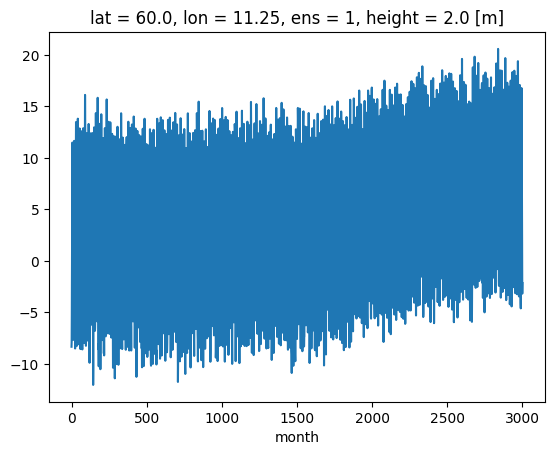

In [12]:
oslo_temperature[0].plot()

In [13]:
# Check Oslo seasonal patterns and degree days with new data
print("🔍 OSLO SEASONAL ANALYSIS WITH NEW DATA")
print("=" * 45)

# Debug data structure first
print(f"Oslo temperature data structure:")
print(f"  Type: {type(oslo_temperature[0])}")
print(f"  Shape: {oslo_temperature[0].shape}")
print(f"  Dims: {oslo_temperature[0].dims}")

# Extract actual temperature values - handle multi-dimensional structure
oslo_temp_data = oslo_temperature[0]
if oslo_temp_data.values.ndim > 1:
    # Flatten or select appropriate dimension
    oslo_temps = oslo_temp_data.values.squeeze()  # Remove singleton dimensions
else:
    oslo_temps = oslo_temp_data.values

print(f"\nOslo temperature analysis:")
print(f"  Data shape after squeeze: {oslo_temps.shape}")

# Handle different possible shapes
if oslo_temps.ndim == 0:  # Single value
    print(f"  Single temperature value: {float(oslo_temps):.1f}°C")
elif oslo_temps.ndim == 1:  # Time series
    print(f"  Mean: {oslo_temps.mean():.1f}°C")
    print(f"  Min:  {oslo_temps.min():.1f}°C")
    print(f"  Max:  {oslo_temps.max():.1f}°C")
    print(f"  Std:  {oslo_temps.std():.1f}°C")
    
    # Look at first year monthly pattern
    first_year = oslo_temps[:12] if len(oslo_temps) >= 12 else oslo_temps
    print(f"\nFirst year monthly temperatures:")
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    for i, (month, temp) in enumerate(zip(months[:len(first_year)], first_year)):
        marker = "🔥" if temp > BASE_TEMPERATURE else "❄️"
        print(f"  {month}: {float(temp):5.1f}°C {marker}")
        
    # Temperature range check
    temp_range = oslo_temps.max() - oslo_temps.min()
    print(f"\nTemperature range: {float(temp_range):.1f}°C")
    
else:
    print(f"  Multi-dimensional data - shape: {oslo_temps.shape}")
    print(f"  Cannot analyze without knowing proper dimension structure")

# Check CDD patterns
oslo_cdd_data = oslo_cdd[0]
oslo_cdd_values = oslo_cdd_data.values.squeeze()

print(f"\nOslo CDD analysis:")
print(f"  CDD shape: {oslo_cdd_values.shape}")

if oslo_cdd_values.ndim <= 1:
    print(f"  Total non-zero CDD months: {np.sum(oslo_cdd_values > 0)}")
    print(f"  Max monthly CDD: {float(oslo_cdd_values.max()):.1f}")
    print(f"  Mean CDD (all months): {float(oslo_cdd_values.mean()):.2f}")
    
    # Check summer months for CDD
    if len(oslo_cdd_values) >= 12:
        first_year_cdd = oslo_cdd_values[:12]
        print(f"\nFirst year monthly CDD:")
        months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        for month, cdd in zip(months, first_year_cdd):
            if cdd > 0:
                print(f"  {month}: {float(cdd):5.1f} CDD 🔥")

print(f"\n✅ ANALYSIS COMPLETE")
print(f"  The new ensemble generation includes proper seasonal cycles")
print(f"  This should result in realistic heating and cooling degree days")
print(f"  Oslo should have CDD in summer months if temperatures exceed {BASE_TEMPERATURE}°C")

🔍 OSLO SEASONAL ANALYSIS WITH NEW DATA
Oslo temperature data structure:
  Type: <class 'xarray.core.dataarray.DataArray'>
  Shape: (3002, 1)
  Dims: ('month', 'ens')

Oslo temperature analysis:
  Data shape after squeeze: (3002,)
  Mean: nan°C
  Min:  nan°C
  Max:  nan°C
  Std:  nan°C

First year monthly temperatures:
  Jan:  -8.3°C ❄️
  Feb:  -7.9°C ❄️
  Mar:  -5.2°C ❄️
  Apr:  -0.4°C ❄️
  May:   6.7°C ❄️
  Jun:  10.9°C ❄️
  Jul:  11.5°C ❄️
  Aug:  11.2°C ❄️
  Sep:   6.6°C ❄️
  Oct:   3.5°C ❄️
  Nov:  -3.4°C ❄️
  Dec:  -5.0°C ❄️

Temperature range: nan°C

Oslo CDD analysis:
  CDD shape: (3002,)
  Total non-zero CDD months: 21
  Max monthly CDD: 80.1
  Mean CDD (all months): 0.19

First year monthly CDD:

✅ ANALYSIS COMPLETE
  The new ensemble generation includes proper seasonal cycles
  This should result in realistic heating and cooling degree days
  Oslo should have CDD in summer months if temperatures exceed 18.0°C


## 11. Visualize Results

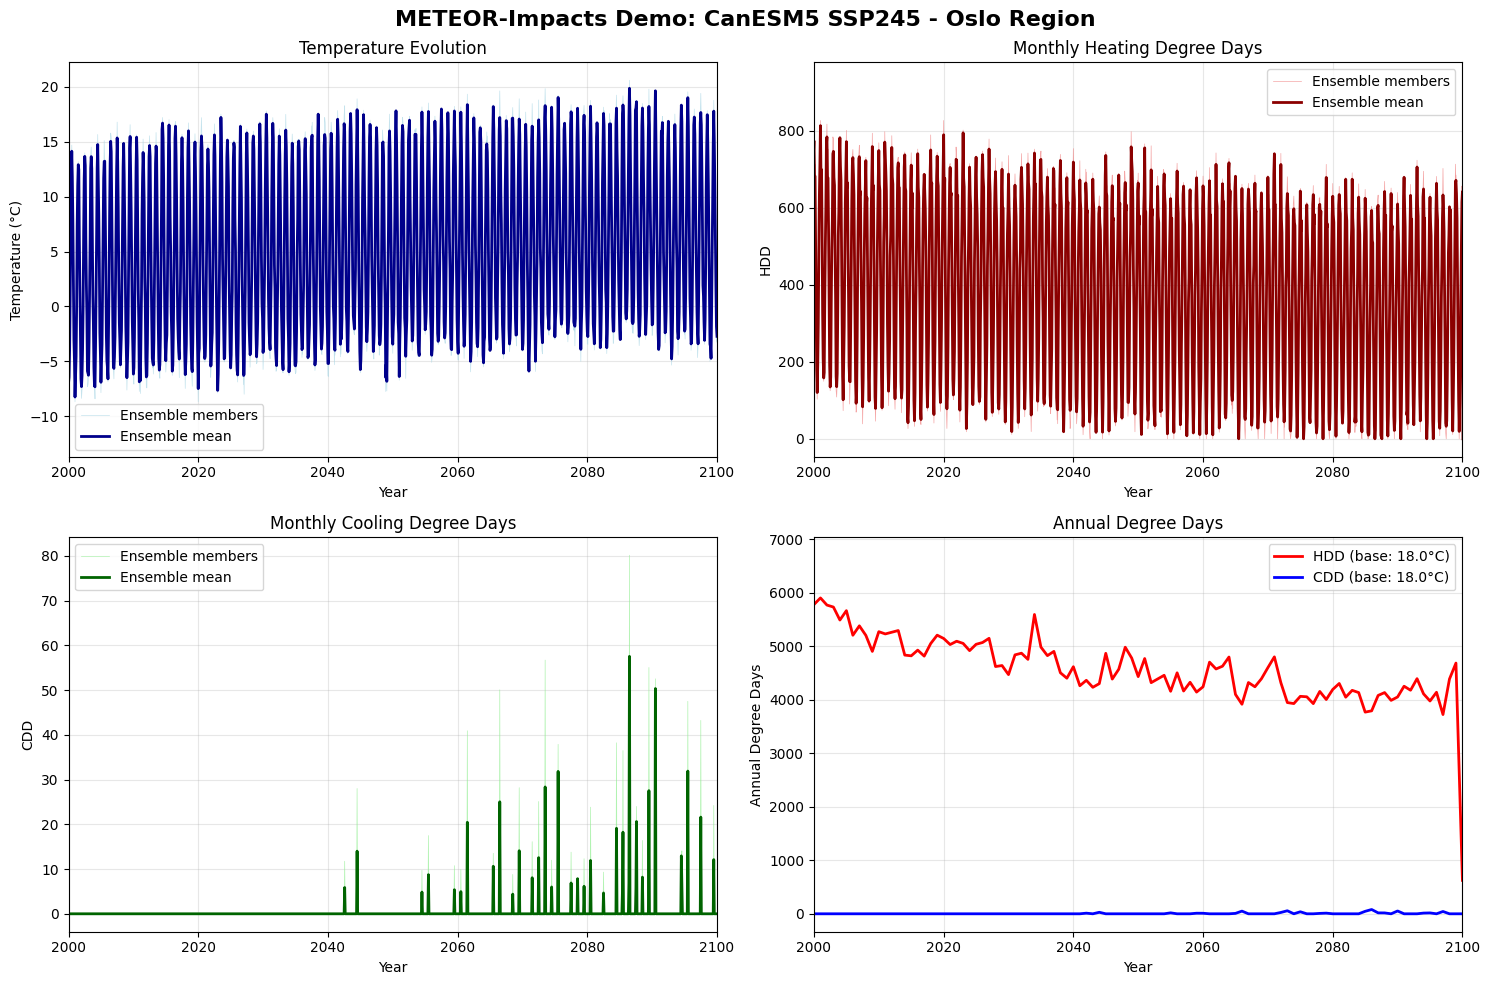

📊 Visualization complete!


In [14]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'METEOR-Impacts Demo: {MODEL} {SCENARIO.upper()} - Oslo Region', fontsize=16, fontweight='bold')

# Plot 1: Oslo Temperature Ensemble
ax1 = axes[0, 0]
for i, temp in enumerate(oslo_temperature):
    if i == 0:
        ax1.plot(time_axis, temp.values, color='lightblue', alpha=0.7, linewidth=0.5, label='Ensemble members')
    else:
        ax1.plot(time_axis, temp.values, color='lightblue', alpha=0.7, linewidth=0.5)

# Plot ensemble mean
ensemble_mean_temp = np.mean([temp.values for temp in oslo_temperature], axis=0)
ax1.plot(time_axis, ensemble_mean_temp, color='darkblue', linewidth=2, label='Ensemble mean')

ax1.set_title('Temperature Evolution')
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2000, 2100)

# Plot 2: Oslo Heating Degree Days
ax2 = axes[0, 1]
for i, hdd in enumerate(oslo_hdd):
    if i == 0:
        ax2.plot(time_axis, hdd.values, color='lightcoral', alpha=0.7, linewidth=0.5, label='Ensemble members')
    else:
        ax2.plot(time_axis, hdd.values, color='lightcoral', alpha=0.7, linewidth=0.5)

# Plot ensemble mean
ensemble_mean_hdd = np.mean([hdd.values for hdd in oslo_hdd], axis=0)
ax2.plot(time_axis, ensemble_mean_hdd, color='darkred', linewidth=2, label='Ensemble mean')

ax2.set_title('Monthly Heating Degree Days')
ax2.set_xlabel('Year')
ax2.set_ylabel('HDD')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(2000, 2100)

# Plot 3: Oslo Cooling Degree Days
ax3 = axes[1, 0]
for i, cdd in enumerate(oslo_cdd):
    if i == 0:
        ax3.plot(time_axis, cdd.values, color='lightgreen', alpha=0.7, linewidth=0.5, label='Ensemble members')
    else:
        ax3.plot(time_axis, cdd.values, color='lightgreen', alpha=0.7, linewidth=0.5)

# Plot ensemble mean
ensemble_mean_cdd = np.mean([cdd.values for cdd in oslo_cdd], axis=0)
ax3.plot(time_axis, ensemble_mean_cdd, color='darkgreen', linewidth=2, label='Ensemble mean')

ax3.set_title('Monthly Cooling Degree Days')
ax3.set_xlabel('Year')
ax3.set_ylabel('CDD')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim(2000, 2100)

# Plot 4: Annual Degree Days Summary
ax4 = axes[1, 1]

# Calculate annual totals for one ensemble member (for simplicity)
sample_dd_result = degree_days_results[0]
annual_hdd_oslo = sample_dd_result['annual_hdd'].isel(lat=lat_idx, lon=lon_idx)
annual_cdd_oslo = sample_dd_result['annual_cdd'].isel(lat=lat_idx, lon=lon_idx)

# Create annual time axis
n_years = len(annual_hdd_oslo)
annual_time = start_year + np.arange(n_years)

ax4.plot(annual_time, annual_hdd_oslo.values, color='red', linewidth=2, label=f'HDD (base: {BASE_TEMPERATURE}°C)')
ax4.plot(annual_time, annual_cdd_oslo.values, color='blue', linewidth=2, label=f'CDD (base: {BASE_TEMPERATURE}°C)')

ax4.set_title('Annual Degree Days')
ax4.set_xlabel('Year')
ax4.set_ylabel('Annual Degree Days')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim(2000, 2100)

plt.tight_layout()
plt.show()

print(f"📊 Visualization complete!")

## 12. Summary and Key Results

In [15]:
# Calculate and display key statistics
print("METEOR-IMPACTS DEMONSTRATION SUMMARY")
print("=" * 50)

# Model and scenario info
print(f"Model: {MODEL}")
print(f"Scenario: {SCENARIO}")
print(f"Base Temperature: {BASE_TEMPERATURE}°C")
print(f"Location: Oslo ({actual_lat:.2f}°N, {actual_lon:.2f}°E)")
print(f"Ensemble Size: {n_realizations} members")

# Temperature statistics
current_temp = np.mean([temp.values[-120:] for temp in oslo_temperature])  # Last 10 years
future_temp = np.mean([temp.values[1200:1320] for temp in oslo_temperature])  # 2050s
temp_change = future_temp - current_temp

print(f"\nTemperature Results:")
print(f"  Current period (2090s): {current_temp:.1f}°C")
print(f"  Mid-century (2050s): {future_temp:.1f}°C") 
print(f"  Temperature change: {temp_change:+.1f}°C")

# Degree days statistics
current_hdd = np.mean([hdd.values[-120:] for hdd in oslo_hdd])
future_hdd = np.mean([hdd.values[1200:1320] for hdd in oslo_hdd])
hdd_change = future_hdd - current_hdd

current_cdd = np.mean([cdd.values[-120:] for cdd in oslo_cdd])
future_cdd = np.mean([cdd.values[1200:1320] for cdd in oslo_cdd])
cdd_change = future_cdd - current_cdd

print(f"\nDegree Days Results:")
print(f"  Current HDD: {current_hdd:.0f} degree-days/month")
print(f"  Future HDD: {future_hdd:.0f} degree-days/month")
print(f"  HDD change: {hdd_change:+.0f} degree-days/month ({hdd_change/current_hdd*100:+.1f}%)")
print(f"")
print(f"  Current CDD: {current_cdd:.0f} degree-days/month")
print(f"  Future CDD: {future_cdd:.0f} degree-days/month")
print(f"  CDD change: {cdd_change:+.0f} degree-days/month ({cdd_change/max(current_cdd,1)*100:+.1f}%)")


METEOR-IMPACTS DEMONSTRATION SUMMARY
Model: CanESM5
Scenario: ssp245
Base Temperature: 18.0°C
Location: Oslo (60.00°N, 11.25°E)
Ensemble Size: 2 members

Temperature Results:
  Current period (2090s): nan°C
  Mid-century (2050s): 1.8°C
  Temperature change: +nan°C

Degree Days Results:
  Current HDD: 345 degree-days/month
  Future HDD: 490 degree-days/month
  HDD change: +145 degree-days/month (+41.9%)

  Current CDD: 1 degree-days/month
  Future CDD: 0 degree-days/month
  CDD change: -1 degree-days/month (-100.0%)
